# Stage 4, multi-seed
### CB1 | Gemma-2-9B-it | JMA-LoRA at r = 8

Retrains the validation-selected joint configuration at training seeds 42, 123 and 456, matching
Stages 2 and 3 so that the three formulations can be compared as paired observations rather than
as isolated numbers.

**Reported in:** Sec. 4.7 of the paper, Table 6.

**Result.** Mean test Macro F1 0.9034, standard deviation 0.0015, ahead of both single-path
formulations on every individual seed.

In [1]:
!pip install -q \
    "transformers>=4.47.0,<4.52.0" \
    "peft>=0.14.0" \
    "bitsandbytes>=0.45.0" \
    "accelerate>=1.2.0" \
    "datasets>=3.0.0" \
    "scikit-learn" \
    tqdm matplotlib seaborn

import importlib.metadata as md
for p in ["torch","transformers","peft","bitsandbytes","accelerate","datasets","numpy","pandas"]:
    try:    print(f"  {p:<16} {md.version(p)}")
    except: print(f"  {p:<16} NOT INSTALLED")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 111.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.24.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
  torch            2.11.0+cu128
  transformers     4.51.3
  peft             0.20.0
  bitsandbytes     0.50.1
  accelerate       1.14.0
  datasets         4.0.0
  numpy            2.1.3
  pandas           2.2.3


---

### Step 2. Imports and Google Drive

Mounts Drive and disables the torchvision path inside `datasets` as a second guard.


In [1]:
import os, random, collections, re
from typing import Dict, List
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef,
)
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments, Trainer, TrainerCallback,
)
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
import bitsandbytes.functional as bnb_F
import bitsandbytes as bnb
from google.colab import drive, userdata

def set_all_seeds(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

def load_hf_token():
    token = userdata.get('HF_TOKEN')
    if token is None:
        raise ValueError("HF_TOKEN not found. Add via Colab Secrets.")
    os.environ['HF_TOKEN'] = token
    print("✓ HuggingFace token loaded.")
    return token

HF_TOKEN = load_hf_token()
drive.mount('/content/drive')
print("✓ Google Drive mounted.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ All random seeds fixed to 42.
✓ HuggingFace token loaded.
Mounted at /content/drive
✓ Google Drive mounted.
✓ Device: cuda
  GPU : NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---

### Step 3. Configuration

Model, dataset paths, split ratios and the fixed seed. `RANDOM_STATE = 42` fixes the data split for every run in the paper.


In [2]:
MODEL_NAME   = "google/gemma-2-9b-it"
NUM_LABELS   = 6
MAX_LENGTH   = 256

LORA_RANK    = 16
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
RANK_SWEEP   = [4, 8, 32]

NUM_EPOCHS       = 1
LEARNING_RATE    = 2e-4
TRAIN_BATCH_SIZE = 4      # 9B model — safe batch with dual adapter on A100
EVAL_BATCH_SIZE  = 16
WEIGHT_DECAY     = 0.01
EVAL_STEPS       = 200
LOGGING_STEPS    = 50
OUTPUT_DIR       = "/content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B"

CB1_PATH             = "/content/drive/MyDrive/Datasets/cb1.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

LABEL_MAPPING = {
    'not_cyberbullying': 0, 'gender': 1, 'religion': 2,
    'ethnicity': 3, 'age': 4, 'other_cyberbullying': 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

print("✓ Configuration loaded.")
print(f"  Stage    : 4a — Generalised LoRA")
print(f"  Formula  : Wf = W(I + UV) + AB")
print(f"  Model    : {MODEL_NAME}")
print(f"  HF token : Required ✓")
print(f"  Batch    : train={TRAIN_BATCH_SIZE} | eval={EVAL_BATCH_SIZE}")
print(f"  LoRA rank: {LORA_RANK}  |  alpha: {LORA_ALPHA}  |  scaling: 1.0")
print(f"  Rank sweep: {RANK_SWEEP}")
print()
print("  ── Stage references (Gemma-2-9B CB1) ──")
print("  S2: r=4: 0.8951 | r=8: 0.8954 | r=16: 0.8986 | r=32: 0.9010★  ↑ monotonic")
print("  S3: r=4: 0.8757 | r=8: 0.8925 | r=16: 0.8937 | r=32: 0.8944   ↑ monotonic")
print("  Eff.Rank: 2815.98 — perfectly constant (strongest Prop 1 validation)")
print("  ★ TARGET: beat S2 r=32 F1=0.9010 — the overall CB1 champion")


✓ Configuration loaded.
  Stage    : 4a — Generalised LoRA
  Formula  : Wf = W(I + UV) + AB
  Model    : google/gemma-2-9b-it
  HF token : Required ✓
  Batch    : train=4 | eval=16
  LoRA rank: 16  |  alpha: 16  |  scaling: 1.0
  Rank sweep: [4, 8, 32]

  ── Stage references (Gemma-2-9B CB1) ──
  S2: r=4: 0.8951 | r=8: 0.8954 | r=16: 0.8986 | r=32: 0.9010★  ↑ monotonic
  S3: r=4: 0.8757 | r=8: 0.8925 | r=16: 0.8937 | r=32: 0.8944   ↑ monotonic
  Eff.Rank: 2815.98 — perfectly constant (strongest Prop 1 validation)
  ★ TARGET: beat S2 r=32 F1=0.9010 — the overall CB1 champion


---

### Step 4. Text preprocessing

URL, mention and whitespace normalisation applied to every split identically.


In [3]:
def preprocess_text_for_llm(text, remove_hashtags=False, remove_emojis=False):
    if not isinstance(text, str): return ""
    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags: text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis: text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3: return ""
    return text

print("Before:", "RT @user123: Check this out http://example.com !!! @someone is so dumb")
print("After: ", preprocess_text_for_llm("RT @user123: Check this out http://example.com !!! @someone is so dumb"))
print("\n✓ Preprocessing function defined.")


Before: RT @user123: Check this out http://example.com !!! @someone is so dumb
After:  Check this out [URL] ! [USER] is so dumb

✓ Preprocessing function defined.


---

### Step 5. Load and clean CB1

Loads the six-class cyberbullying corpus and applies the preprocessing above.


In [4]:
print("═" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("═" * 60)
df = pd.read_csv(CB1_PATH)
print(f"\n[1] Raw dataset loaded: {len(df):,} samples")
df = df.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'label'})
corrupt_mask = df['text'].astype(str).str.strip().isin(['#NAME?','#REF!','#VALUE!','#N/A','nan',''])
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[3] Removed {corrupt_mask.sum()} corrupt rows → {len(df):,} remaining")
df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[4] After preprocessing: {len(df):,} remaining")
text_label_counts = df.groupby('text')['label'].nunique()
conflicting = text_label_counts[text_label_counts > 1].index
df = df[~df['text'].isin(conflicting)].reset_index(drop=True)
print(f"[5] Removed annotation-conflict rows → {len(df):,} remaining")
before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[6] Removed {before-len(df):,} exact duplicates → {len(df):,} remaining")
before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[7] Removed {before-len(df):,} short texts → {len(df):,} remaining")
assert len(set(df['label'].unique()) - set(LABEL_MAPPING.keys())) == 0

print("\n" + "═" * 60)
print("FINAL CB1 CLASS DISTRIBUTION")
print("═" * 60)
counts = df['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")
print(f"\n  Imbalance ratio: {counts.max()/counts.min():.2f}×")


════════════════════════════════════════════════════════════
CB1 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset loaded: 47,692 samples
[3] Removed 0 corrupt rows → 47,692 remaining
[4] After preprocessing: 46,942 remaining
[5] Removed annotation-conflict rows → 43,692 remaining
[6] Removed 358 exact duplicates → 43,334 remaining
[7] Removed 0 short texts → 43,334 remaining

════════════════════════════════════════════════════════════
FINAL CB1 CLASS DISTRIBUTION
════════════════════════════════════════════════════════════
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334

  Imbalance ratio: 1.37×


---

### Step 6. Stratified 75/25 split with near-duplicate removal

TF-IDF cosine near-duplicates above 0.90 are moved out of the test set. **Check this prints `Train: 29,703 | Val: 3,301 | Test: 10,330`.** Those numbers must match every other run in the paper.


In [5]:
print("═" * 60)
print("DATASET SPLITTING — 75% train / 25% test")
print("═" * 60)
train_val_df, test_df = train_test_split(
    df, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=df['label'])
print(f"\n[1] Primary split → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")

print(f"\n[2] Near-duplicate check (threshold: {SIMILARITY_THRESHOLD})...")
all_texts = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs = tfidf_matrix[:len(train_val_df)]
test_vecs = tfidf_matrix[len(train_val_df):]

leaked_indices = []
for start in range(0, len(test_df), 500):
    end = min(start+500, len(test_df))
    batch_sims = cosine_similarity(test_vecs[start:end], train_vecs)
    leaked_mask = batch_sims.max(axis=1) >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())

print(f"    Found {len(leaked_indices)} near-duplicate test samples")
if leaked_indices:
    leaked = test_df.loc[leaked_indices]
    test_df = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df = pd.concat([train_val_df, leaked], ignore_index=True)
    print(f"    Moved → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

overlap = set(train_val_df['text'].tolist()) & set(test_df['text'].tolist())
assert len(overlap) == 0, f"DATA LEAKAGE: {len(overlap)} overlapping samples!"
print("    ✓ Data leakage assertion passed.")

train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FROM_TRAIN, random_state=RANDOM_STATE, stratify=train_val_df['label'])
train_df = train_df.reset_index(drop=True); val_df = val_df.reset_index(drop=True)
print(f"\n[3] Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"    ✓ Test = {len(test_df)/len(df)*100:.1f}% (target: 25.0%)")


════════════════════════════════════════════════════════════
DATASET SPLITTING — 75% train / 25% test
════════════════════════════════════════════════════════════

[1] Primary split → Train+Val: 32,500 | Test: 10,834

[2] Near-duplicate check (threshold: 0.9)...
    Found 504 near-duplicate test samples
    Moved → Train+Val: 33,004 | Test: 10,330
    ✓ Data leakage assertion passed.

[3] Train: 29,703 | Val: 3,301 | Test: 10,330
    ✓ Test = 23.8% (target: 25.0%)


---

### Step 7. Class weights

Inverse-frequency weights. Near-uniform on CB1 because the corpus is balanced.


In [6]:
def get_class_weights(df, label_col='label'):
    counts = df[label_col].value_counts()
    total = len(df); n_classes = len(LABEL_MAPPING)
    weights = [total / (n_classes * counts.get(ID2LABEL[i], 1)) for i in range(n_classes)]
    weights_norm = [w / sum(weights) * n_classes for w in weights]
    print("Class weights:")
    for i, (cls, w) in enumerate(zip(TARGET_NAMES, weights_norm)):
        print(f"  [{i}] {cls:<25} {w:.4f}")
    return weights_norm

print("✓ get_class_weights() defined.")


✓ get_class_weights() defined.


---

### Step 8. Effective rank of the adapted weights

SVD-based numerical rank of the adapted weight matrix, with the 4-bit base weights dequantised first. This is the estimator behind the RQ2 analysis.


In [7]:
def calculate_effective_rank_generalised(model, threshold_ratio=1e-3):
    full_ranks, uv_ranks, ab_ranks, per_layer = [], [], [], []
    skipped = 0

    for name, module in model.named_modules():
        if type(module).__name__ != 'GeneralisedLoRALayer':
            continue
        try:
            U = module.lora_U.data.float(); V = module.lora_V.data.float()
            A = module.lora_A.data.float(); B = module.lora_B.data.float()
            UV = U @ V; AB = A @ B

            S_uv = torch.linalg.svdvals(UV)
            r_uv = int((S_uv > threshold_ratio * S_uv[0]).sum()) if S_uv[0] > 0 else 0
            uv_ranks.append(r_uv)

            S_ab = torch.linalg.svdvals(AB)
            r_ab = int((S_ab > threshold_ratio * S_ab[0]).sum()) if S_ab[0] > 0 else 0
            ab_ranks.append(r_ab)

            weight_obj = module.inner.weight
            try:
                if hasattr(weight_obj, 'quant_state'):
                    W = bnb_F.dequantize_4bit(weight_obj.data, weight_obj.quant_state).float()
                else:
                    W = weight_obj.data.float()
            except Exception as e:
                if skipped == 0: print(f"  ℹ First dequant error: {type(e).__name__}: {e}")
                skipped += 1; continue

            if W.shape[0] == module.m and W.shape[1] == module.n:
                pass
            elif W.shape[0] == module.n and W.shape[1] == module.m:
                W = W.T.contiguous()
            else:
                if skipped == 0: print(f"  ℹ Shape mismatch: W={list(W.shape)}, m={module.m}, n={module.n}")
                skipped += 1; continue

            Wf = W + W @ UV + AB
            S_Wf = torch.linalg.svdvals(Wf)
            r_Wf = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0
            full_ranks.append(r_Wf)
            per_layer.append({'layer': name, 'rank_Wf': r_Wf, 'rank_UV': r_uv, 'rank_AB': r_ab})
        except Exception:
            skipped += 1; continue

    if skipped > 0: print(f"  ℹ {skipped} layers skipped")
    if not full_ranks: print("  ⚠ No GeneralisedLoRALayer found")

    return {
        "avg_eff_rank_Wf": float(np.mean(full_ranks)) if full_ranks else 0.0,
        "avg_eff_rank_UV": float(np.mean(uv_ranks)) if uv_ranks else 0.0,
        "avg_eff_rank_AB": float(np.mean(ab_ranks)) if ab_ranks else 0.0,
        "layer_count": len(full_ranks), "per_layer_ranks": per_layer,
    }

print("✓ calculate_effective_rank_generalised() defined.")
print("  Gemma-2-9B reference: 2815.98 (perfectly constant in S2 and S3)")


✓ calculate_effective_rank_generalised() defined.
  Gemma-2-9B reference: 2815.98 (perfectly constant in S2 and S3)


---

### Step 9. Evaluation metrics

Macro F1 as the primary metric, MCC as the secondary, plus the per-class report.


In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    accuracy = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}

def evaluate_dataset(y_true, y_pred, dataset_name):
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, labels=list(range(NUM_LABELS)),
                                target_names=TARGET_NAMES, zero_division=0, digits=4))
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{dataset_name}')
    axes[0].tick_params(axis='x', rotation=45)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised)\n{dataset_name}')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()
    return {'accuracy': accuracy, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
            'balanced_accuracy': bal_accuracy, 'mcc': mcc}

def make_predictions(model, df_test, tokenizer, batch_size=32):
    model.eval(); all_preds = []
    texts = df_test['text'].tolist()
    for start in range(0, len(texts), batch_size):
        enc = tokenizer(texts[start:start+batch_size], padding='max_length',
                        truncation=True, max_length=MAX_LENGTH, return_tensors='pt').to(model.device)
        with torch.no_grad():
            logits = model(**enc).logits
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy().tolist())
    df_out = df_test.copy(); df_out['predictions'] = all_preds
    return df_out

print("✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.")


✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.


---

### Step 10. Training-stability callback and weighted-loss trainer

Records the loss and validation curves during training, and applies class weights to the loss.


In [9]:
class StabilityCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []; self.val_metrics = collections.defaultdict(list); self.val_steps = []
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0: return
        if 'loss' in logs: self.train_losses.append((state.global_step, float(logs['loss'])))
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        self.val_steps.append(state.global_step)
        for k, v in metrics.items(): self.val_metrics[k.replace('eval_','')].append(float(v))
    def get_stability_report(self):
        report = {}
        if self.train_losses:
            arr = np.array([l for (_,l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall'] = float(np.std(arr))
            report['loss_cv_overall'] = float(np.std(arr)/np.mean(arr)) if np.mean(arr) > 0 else 0.0
        for m, vals in self.val_metrics.items():
            if len(vals) > 1:
                a = np.array(vals)
                report[f'val_{m}_std'] = float(np.std(a)); report[f'val_{m}_range'] = float(a.max()-a.min())
                report[f'val_{m}_best'] = float(a.max()); report[f'val_{m}_final'] = float(a[-1])
        report['stability_score'] = round((report.get('loss_cv_overall',0)*0.5) + (report.get('val_f1_std',0)*0.5), 6)
        return report
    def plot_stability_curves(self, stage_label='Stage 4', save_path=None):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        if self.train_losses:
            steps = [s for (s,_) in self.train_losses]; losses = [l for (_,l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7, alpha=0.5, label='Step loss')
            w = min(20, len(losses))
            if len(losses) >= w:
                roll = np.convolve(losses, np.ones(w)/w, mode='valid')
                ax1.plot(steps[w-1:], roll, color='navy', linewidth=2.2, label=f'Rolling mean (w={w})')
            ax1.set_title(f'{stage_label}\nTraining Loss'); ax1.set_xlabel('Step'); ax1.set_ylabel('Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
        if self.val_steps:
            ax2r = ax2.twinx() if 'mcc' in self.val_metrics else None
            if 'f1' in self.val_metrics:
                f1v = self.val_metrics['f1']
                ax2.plot(self.val_steps, f1v, 'o-', color='forestgreen', linewidth=2, markersize=5, label='Macro F1')
                mu, sd = float(np.mean(f1v)), float(np.std(f1v))
                ax2.axhline(mu, color='forestgreen', linestyle=':', alpha=0.6)
                ax2.fill_between(self.val_steps, [mu-sd]*len(self.val_steps), [mu+sd]*len(self.val_steps),
                                 color='forestgreen', alpha=0.10, label=f'±1 std (={sd:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen'); ax2.tick_params(axis='y', labelcolor='forestgreen')
            if ax2r and 'mcc' in self.val_metrics:
                ax2r.plot(self.val_steps, self.val_metrics['mcc'], 's--', color='darkorange',
                          linewidth=1.5, markersize=4, label='MCC', alpha=0.8)
                ax2r.set_ylabel('MCC', color='darkorange'); ax2r.tick_params(axis='y', labelcolor='darkorange')
            l1, lb1 = ax2.get_legend_handles_labels()
            l2, lb2 = (ax2r.get_legend_handles_labels() if ax2r else ([], []))
            ax2.legend(l1+l2, lb1+lb2, fontsize=9)
            ax2.set_title(f'{stage_label}\nValidation Metrics'); ax2.set_xlabel('Step'); ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight'); print(f"✓ Saved → {save_path}")
        plt.show()

class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32) if class_weights is not None else None
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels"); outputs = model(**inputs); logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device)) if self.class_weights is not None else nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("✓ StabilityCallback, CustomTrainer defined.")


✓ StabilityCallback, CustomTrainer defined.


---

### Step 11a. Rank-preservation diagnostics

**Added for the revision, the rank-preservation analysis.** Measures the spectral norm of UV, the smallest singular value of I + UV, and its condition number, for every adapted projection. This is what tests the sufficient condition of Proposition 2 directly rather than assuming it.


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# RANK-PRESERVATION DIAGNOSTICS
# Proposition 2 requires ||UV||_2 < 1 for I+UV to be invertible.
# The paper asserts this; this measures whether training actually stayed there.
# No extra training runs: it reads the model already in memory.
# ═══════════════════════════════════════════════════════════════════════════
def measure_rank_conditions(model):
    rows = []
    for name, module in model.named_modules():
        if type(module).__name__ != 'GeneralisedLoRALayer':
            continue
        try:
            U = module.lora_U.detach().float()      # (n, r)
            V = module.lora_V.detach().float()      # (r, n)
            UV = (U @ V) * module.scaling           # scaling applied as in forward
            n  = UV.shape[0]
            L1 = torch.eye(n, device=UV.device, dtype=UV.dtype) + UV
            s_uv = torch.linalg.svdvals(UV)
            s_l1 = torch.linalg.svdvals(L1)
            rows.append({
                'layer': name,
                'spectral_norm_UV': float(s_uv[0]),
                'satisfies_prop2':  bool(float(s_uv[0]) < 1.0),
                'sigma_min_L1':     float(s_l1[-1]),
                'sigma_max_L1':     float(s_l1[0]),
                'cond_L1':          float(s_l1[0] / max(float(s_l1[-1]), 1e-12)),
            })
        except Exception as e:
            print(f'   [skip] {name}: {e}')
    if not rows:
        return {}, []
    import numpy as _np
    a = lambda k: _np.array([r[k] for r in rows])
    summary = {
        'layers_measured':              len(rows),
        'max_spectral_norm_UV':         float(a('spectral_norm_UV').max()),
        'mean_spectral_norm_UV':        float(a('spectral_norm_UV').mean()),
        'frac_layers_satisfying_prop2': float(a('satisfies_prop2').mean()),
        'min_sigma_min_L1':             float(a('sigma_min_L1').min()),
        'max_cond_L1':                  float(a('cond_L1').max()),
        'mean_cond_L1':                 float(a('cond_L1').mean()),
    }
    print('\n[6b] Rank-preservation conditions (Proposition 2):')
    print(f'      layers measured      : {summary["layers_measured"]}')
    print(f'      max ||UV||_2         : {summary["max_spectral_norm_UV"]:.4f}   (needs < 1)')
    print(f'      satisfying Prop 2    : {100*summary["frac_layers_satisfying_prop2"]:.1f}% of layers')
    print(f'      min sigma_min(I+UV)  : {summary["min_sigma_min_L1"]:.4e}')
    print(f'      max condition number : {summary["max_cond_L1"]:.2f}')
    if summary['frac_layers_satisfying_prop2'] < 1.0:
        print('      NOTE: training left the Proposition 2 regime in some layers.')
        print('            Report this. It is a finding, not a failure.')
    return summary, rows

print("✓ measure_rank_conditions() defined.")


✓ measure_rank_conditions() defined.


---

### Step 11b. Generalised LoRA layer and training function

The joint formulation Wf = W(I + UV) + AB, and the function that trains and evaluates one configuration. Logs the validation score used for model selection and passes the seed through to `TrainingArguments`.


In [11]:
class GeneralisedLoRALayer(nn.Module):
    """
    Dual adapter: Wf = W(I + UV) + AB
    Forward: y = W·x + scaling·W·(U·(V·x)) + scaling·A·(B·x)
    Init: V=0, B=0 → Wf=W at start. Scaling = alpha/rank = 1.0.
    Params on inner.weight.device from init — no .to() in forward.
    """
    def __init__(self, base_layer, rank, dropout=0.05, alpha=None):
        super().__init__()
        self.rank = rank
        self.alpha = alpha if alpha is not None else rank
        self.scaling = self.alpha / self.rank

        inner = base_layer.base_layer if hasattr(base_layer, 'base_layer') else base_layer
        if hasattr(inner, 'in_features'):
            n, m = inner.in_features, inner.out_features
        elif hasattr(inner, 'weight'):
            n, m = inner.weight.shape[1], inner.weight.shape[0]
        else:
            raise ValueError(f"Cannot determine dims from {type(inner)}")

        self.n = n; self.m = m; self.inner = inner
        _dev = self.inner.weight.device

        self.lora_U = nn.Parameter(torch.empty(n, rank, device=_dev))
        self.lora_V = nn.Parameter(torch.zeros(rank, n, device=_dev))
        self.lora_A = nn.Parameter(torch.empty(m, rank, device=_dev))
        self.lora_B = nn.Parameter(torch.zeros(rank, n, device=_dev))

        nn.init.normal_(self.lora_U, mean=0.0, std=0.01)
        nn.init.normal_(self.lora_A, mean=0.0, std=0.01)

        self.dropout = nn.Dropout(p=dropout) if dropout > 0.0 else nn.Identity()
        for param in self.inner.parameters(): param.requires_grad = False

    def forward(self, x):
        base_out = self.inner(x)
        x_drop = self.dropout(x)

        lora_vx  = x_drop @ self.lora_V.T
        lora_uvx = lora_vx @ self.lora_U.T
        mult_out = self.inner(lora_uvx)

        lora_bx = x_drop @ self.lora_B.T
        add_out = lora_bx @ self.lora_A.T

        return base_out + self.scaling * mult_out + self.scaling * add_out


def apply_generalised_lora_over_peft(model, target_modules, rank, dropout=0.05, alpha=None):
    from peft.tuners.lora import LoraLayer
    if alpha is None: alpha = rank
    replaced = 0
    module_dict = dict(model.named_modules())

    for name, module in list(model.named_modules()):
        if not isinstance(module, LoraLayer): continue
        if not any(name.endswith(f'.{t}') or name == t for t in target_modules): continue
        parts = name.rsplit('.', 1)
        if len(parts) == 2:
            parent = module_dict.get(parts[0])
            if parent is None: continue
            attr_name = parts[1]
        else:
            parent = model; attr_name = name
        gen_layer = GeneralisedLoRALayer(module, rank=rank, dropout=dropout, alpha=alpha)
        setattr(parent, attr_name, gen_layer)
        replaced += 1

    print(f"  ✓ Replaced {replaced} PEFT LoraLayers with GeneralisedLoRALayer")
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return model, trainable, total


def run_generalised_lora(train_df, val_df, test_df, lora_rank, run_label=''):
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank
    label = run_label or f'GeneralisedLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 4 — GENERALISED LoRA  |  {label}')
    print(f'  Model: {MODEL_NAME}  |  Rank: {lora_rank}  |  Scaling: 1.0')
    print(f'  Formula: Wf = W(I + UV) + AB   [both paths active]')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab: {tokenizer.vocab_size:,}')

    def tokenise(examples):
        return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=MAX_LENGTH)

    print('[2] Preparing datasets...')
    train_m = train_df.copy(); val_m = val_df.copy(); test_m = test_df.copy()
    for s in [train_m, val_m, test_m]:
        s['label'] = s['label'].map(LABEL_MAPPING)
        assert s['label'].notnull().all()
    hf_train = Dataset.from_pandas(train_m[['text','label']].reset_index(drop=True)).map(tokenise, batched=True, remove_columns=['text'])
    hf_val = Dataset.from_pandas(val_m[['text','label']].reset_index(drop=True)).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch'); hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.bfloat16)

    lora_config = LoraConfig(
        r=lora_rank, lora_alpha=lora_alpha, target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT, bias='none', task_type='SEQ_CLS')

    print('[3] Loading model (4-bit NF4 QLoRA)...')
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, quantization_config=quant_config, num_labels=NUM_LABELS,
        torch_dtype=torch.bfloat16, device_map='auto', token=HF_TOKEN)
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_config)
    print('   PEFT shell registered.')

    print('[4] Injecting GeneralisedLoRALayer...')
    model, trainable, total = apply_generalised_lora_over_peft(
        model, TARGET_MODULES, rank=lora_rank, dropout=LORA_DROPOUT, alpha=lora_alpha)
    print(f'   Trainable: {trainable:,} | Total: {total:,} | {100*trainable/total:.4f}%')

    class_weights = get_class_weights(train_df)

    training_args = TrainingArguments(
        output_dir=run_dir, num_train_epochs=NUM_EPOCHS,
        seed=RANDOM_STATE,          # varies with the multi-seed loop
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
        eval_strategy='steps', eval_steps=EVAL_STEPS,
        logging_steps=LOGGING_STEPS, save_strategy='no',
        load_best_model_at_end=False,
        fp16=False, bf16=True,
        report_to='none', remove_unused_columns=False,
    )

    stability_cb = StabilityCallback()
    trainer = CustomTrainer(
        model=model, args=training_args,
        train_dataset=hf_train, eval_dataset=hf_val,
        compute_metrics=compute_metrics, callbacks=[stability_cb],
        class_weights=class_weights)

    print(f'\n[5] Training (Wf = W(I+UV) + AB, r={lora_rank})...')
    train_result = trainer.train()
    train_runtime_s = train_result.metrics.get('train_runtime', 0)
    print(f'   Time: {train_runtime_s:.0f}s ({train_runtime_s/3600:.2f} hrs)')

    stab_report = stability_cb.get_stability_report()
    # ---- VALIDATION scores: the metric rank selection must use (Rev 5a, 6b) ----
    # compute_metrics returns 'f1', so the stability report keys are val_f1_*
    val_best  = stab_report.get('val_f1_best',  float('nan'))
    val_final = stab_report.get('val_f1_final', float('nan'))
    print(f'   VALIDATION Macro F1 — best: {val_best:.4f} | final: {val_final:.4f}'
          f'   <-- rank selection uses THIS, not the test score')
    stab_score = stab_report.get('stability_score', float('nan'))
    print(f'   Stability: {stab_score:.4f}', end='  ')
    if stab_score < 0.05: print('✅ Very stable')
    elif stab_score < 0.15: print('🟡 Acceptable')
    else: print('🔴 Unstable')

    stability_cb.plot_stability_curves(
        stage_label=f'Stage 4 Gemma-2-9B — Generalised LoRA (r={lora_rank})',
        save_path=os.path.join(run_dir, f'stability_{label}.png'))

    # ── Note 25 Aug: test evaluation now runs BEFORE the rank diagnostics,
    # and a first CSV is written as soon as the scores exist. The diagnostics
    # take several minutes of GPU time, and a session drop during them used to
    # discard an entire 3.4-hour run. The CSV is rewritten with the diagnostics
    # once they finish, so nothing is lost either way.
    print('\n[6] Evaluating on test set...')
    test_preds = make_predictions(model, test_m, tokenizer)
    eval_results = evaluate_dataset(
        test_m['label'].tolist(), test_preds['predictions'].tolist(), f'Stage4_CB1_{label}')

    _base = {
        'model': 'Gemma-2-9B', 'stage': '4a', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB1', 'rank': lora_rank, 'trainable_params': trainable,
        'val_macro_f1_best': val_best, 'val_macro_f1_final': val_final,
        'macro_f1': eval_results['macro_f1'], 'mcc': eval_results['mcc'],
        'accuracy': eval_results['accuracy'], 'balanced_accuracy': eval_results['balanced_accuracy'],
        'stability_score': stab_score, 'train_runtime_s': train_runtime_s,
    }
    pd.DataFrame([_base]).to_csv(os.path.join(run_dir, f'{label}_results.csv'), index=False)
    print(f'   SAFETY SAVE: scores written to {label}_results.csv before the diagnostics')

    print('\n[7] Computing effective rank and rank-preservation diagnostics...')
    try:
        rank_info = calculate_effective_rank_generalised(model)
        diag, diag_rows = measure_rank_conditions(model)
        print(f'   Eff.Rank Wf: {rank_info["avg_eff_rank_Wf"]:.2f}  ← S2: 2815.98 | S3: 2815.98')
        print(f'   Eff.Rank UV: {rank_info["avg_eff_rank_UV"]:.2f} | AB: {rank_info["avg_eff_rank_AB"]:.2f}')
        print(f'   Layers: {rank_info["layer_count"]}')
    except Exception as _e:
        print(f'   DIAGNOSTICS FAILED ({_e}). Scores above are already saved and are unaffected.')
        rank_info = {'avg_eff_rank_Wf': float('nan'), 'avg_eff_rank_UV': float('nan'),
                     'avg_eff_rank_AB': float('nan'), 'layer_count': 0}
        diag, diag_rows = {}, []

    row = {
        'model': 'Gemma-2-9B', 'stage': '4a', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB1', 'rank': lora_rank, 'trainable_params': trainable,
        'val_macro_f1_best': val_best, 'val_macro_f1_final': val_final,
        'macro_f1': eval_results['macro_f1'], 'mcc': eval_results['mcc'],
        'accuracy': eval_results['accuracy'], 'balanced_accuracy': eval_results['balanced_accuracy'],
        'avg_eff_rank_Wf': rank_info['avg_eff_rank_Wf'],
        'avg_eff_rank_UV': rank_info['avg_eff_rank_UV'],
        'avg_eff_rank_AB': rank_info['avg_eff_rank_AB'],
        'stability_score': stab_score, 'train_runtime_s': train_runtime_s,
        **{k: diag.get(k) for k in ('max_spectral_norm_UV','mean_spectral_norm_UV',
                                    'frac_layers_satisfying_prop2','min_sigma_min_L1',
                                    'max_cond_L1','mean_cond_L1')},
    }
    pd.DataFrame([row]).to_csv(os.path.join(run_dir, f'{label}_results.csv'), index=False)
    if diag_rows:
        pd.DataFrame(diag_rows).to_csv(
            os.path.join(run_dir, f'{label}_rank_diagnostics.csv'), index=False)
    print(f'\n✓ Results saved → {run_dir}')

    del model, trainer; torch.cuda.empty_cache()

    return {**eval_results, 'lora_rank': lora_rank, 'trainable_params': trainable,
            'val_macro_f1_best': val_best, 'val_macro_f1_final': val_final,
            'rank_diagnostics': diag,
            'avg_eff_rank_Wf': rank_info['avg_eff_rank_Wf'],
            'avg_eff_rank_UV': rank_info['avg_eff_rank_UV'],
            'avg_eff_rank_AB': rank_info['avg_eff_rank_AB'],
            'stability_score': stab_score, 'stability_report': stab_report,
            'stability_cb': stability_cb, 'train_runtime_s': train_runtime_s}


print("✓ GeneralisedLoRALayer defined.  (device-aware init, no .to() in forward)")
print("✓ apply_generalised_lora_over_peft() defined.  (rsplit fix)")
print("✓ run_generalised_lora() defined.")


✓ GeneralisedLoRALayer defined.  (device-aware init, no .to() in forward)
✓ apply_generalised_lora_over_peft() defined.  (rsplit fix)
✓ run_generalised_lora() defined.


---

### Step 11c. datasets compatibility guard

Belt and braces against the torchvision import clash.


In [12]:
import datasets
datasets.config.TORCHVISION_AVAILABLE = False
print("datasets torchvision path disabled:", datasets.config.TORCHVISION_AVAILABLE)

datasets torchvision path disabled: False


---

### Step 12. Multi-seed validation at the selected rank

**This is the only cell that trains.** It reruns the validation-selected configuration (r = 8) at seeds 123 and 456. Seed 42 already exists from the rank sweep and is loaded from Drive, giving three seeds in total.

The data split stays fixed at 42 so every run is scored on the same test set. Only the training seed changes.

**Resume-safe.** If the session drops, run this cell again and it continues from whatever is already on Drive.

 About 7 hours.


recovered seeds : [42, 123]
still to run    : [456]

------------------------------------------------------------
  Seed 456  at r = 8
------------------------------------------------------------
✓ All random seeds fixed to 456.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r8_seed456
  Model: google/gemma-2-9b-it  |  Rank: 8  |  Scaling: 1.0
  Formula: Wf = W(I + UV) + AB   [both paths active]

[1] Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer...
  ✓ Replaced 168 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable: 18,945,024 | Total: 5,098,874,368 | 0.3716%
Class weights:
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=8)...


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.769600,0.766073,0.822781,0.800910,0.790331
400,0.771800,0.712668,0.838534,0.812969,0.806926
600,0.718800,0.558266,0.863375,0.844947,0.836401
800,0.618800,0.631387,0.863678,0.843669,0.836422
1000,0.707600,0.613667,0.848834,0.820245,0.821371
1200,0.666500,0.443523,0.875492,0.862201,0.850270
1400,0.550000,0.510171,0.873372,0.857918,0.850790
1600,0.562400,0.708277,0.850651,0.826524,0.826014
1800,0.472200,0.453632,0.888216,0.874602,0.865504
2000,0.449200,0.562157,0.878219,0.863046,0.855222


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

   Time: 11892s (3.30 hrs)
   VALIDATION Macro F1 — best: 0.9135 | final: 0.9135   <-- rank selection uses THIS, not the test score
   Stability: 0.2114  🔴 Unstable
✓ Saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r8_seed456/stability_GeneralisedLoRA_r8_seed456.png


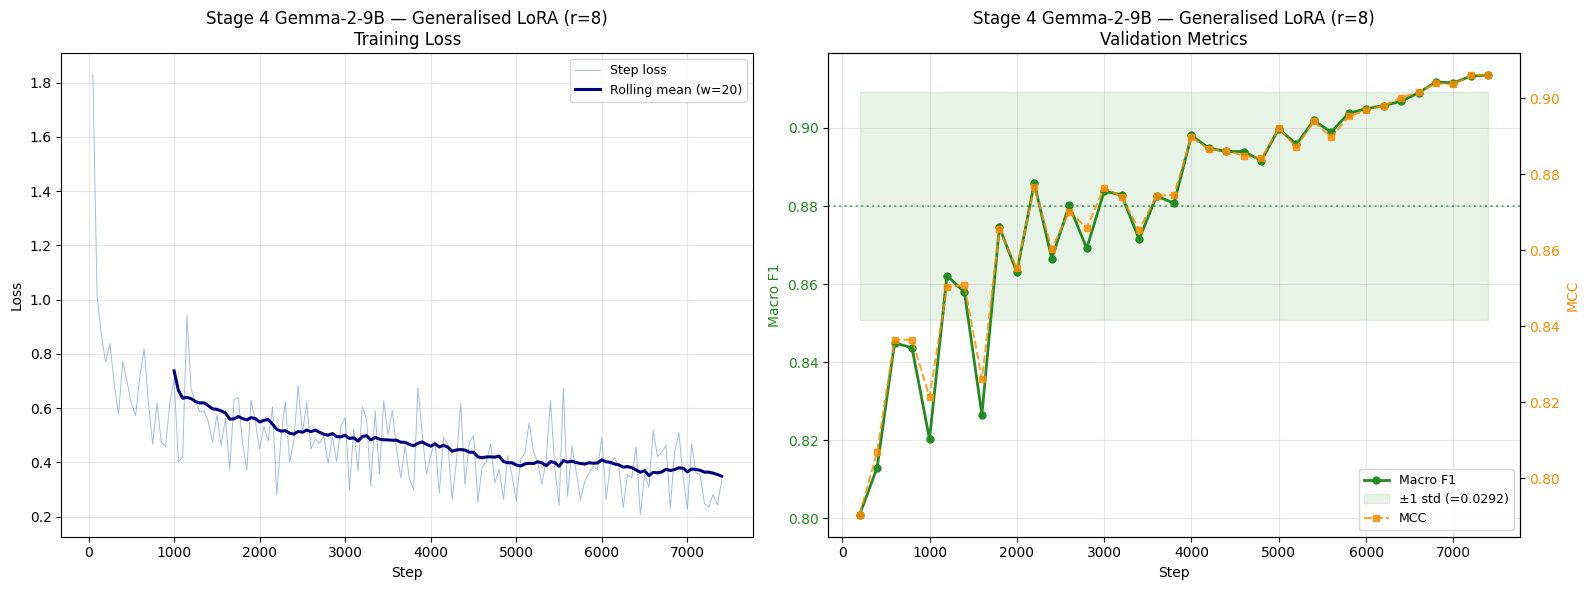


[6] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r8_seed456
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9131
  Macro F1          : 0.9017  ← PRIMARY METRIC
  Weighted F1       : 0.9130
  Balanced Accuracy : 0.9022
  MCC               : 0.8954  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7748    0.7346    0.7541      1424
             gender     0.9202    0.9027    0.9113      1788
           religion     0.9623    0.9711    0.9667      1971
          ethnicity     0.9911    0.9857    0.9884      1812
                age     0.9779    0.9774    0.9777      1950
other_cyberbullying     0.7847    0.8419    0.8123      1385

           accuracy                         0.9131     10330
          macro avg     0.9018    0.9022    0.9017     10330
       weighted avg

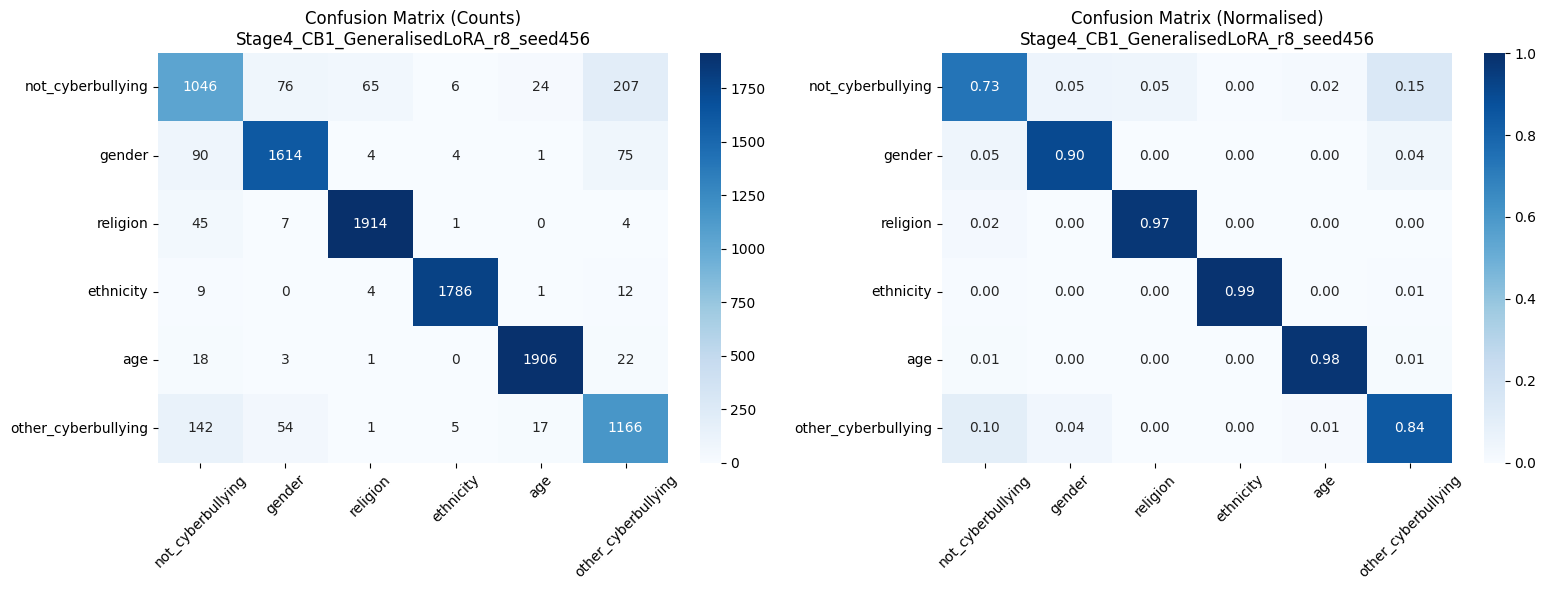

   SAFETY SAVE: scores written to GeneralisedLoRA_r8_seed456_results.csv before the diagnostics

[7] Computing effective rank and rank-preservation diagnostics...


/tmp/ipykernel_1907/1986088909.py:13: UserWarning: torch.linalg.svd: During SVD computation with the selected cusolver driver, batches 0 failed to converge. A more accurate method will be used to compute the SVD as a fallback. Check doc at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html (Triggered internally at /pytorch/aten/src/ATen/native/cuda/linalg/BatchLinearAlgebraLib.cpp:692.)
  S_uv = torch.linalg.svdvals(UV)



[6b] Rank-preservation conditions (Proposition 2):
      layers measured      : 168
      max ||UV||_2         : 4.0216   (needs < 1)
      satisfying Prop 2    : 4.8% of layers
      min sigma_min(I+UV)  : 2.5936e-01
      max condition number : 15.81
      NOTE: training left the Proposition 2 regime in some layers.
            Report this. It is a finding, not a failure.
   Eff.Rank Wf: 2815.98  ← S2: 2815.98 | S3: 2815.98
   Eff.Rank UV: 8.00 | AB: 8.00
   Layers: 168

✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r8_seed456
   checkpoint written after seed 456  |  elapsed 4.05 h

MULTI-SEED  --  Stage 4, joint  --  CB1, Gemma-2-9B, r = 8
  Wf = W(I + UV) + AB
  seed |  VAL Macro F1 |  TEST Macro F1 |      MCC
    42 |        0.9189 |         0.9044 |   0.8984
   123 |        0.9168 |         0.9041 |   0.8972
   456 |        0.9135 |         0.9017 |   0.8954
-------------------------------------------------------------------------

In [13]:
# ═════════════════════════════════════════════════════════════════════════════
#  STEP 12. MULTI-SEED VALIDATION  --  Stage 4, joint, CB1, Gemma-2-9B, r = 8
#  Reviewer comments 5b, 6a, 4a
#
#  NOTE ON NAMING. This notebook does not use the same column or file names as
#  the Stage 2 and Stage 3 notebooks:
#      file   LABEL_results.csv        (Stages 2/3: results_LABEL.csv)
#      rank   'rank'                   (Stages 2/3: 'lora_rank')
#      val    'val_macro_f1_best'      (Stages 2/3: 'val_f1_best')
#  _norm() below maps whichever names are present onto one canonical set, so
#  this cell works regardless of which convention wrote the file.
#
#  RESUME-SAFE. Re-run after a disconnect and it continues from Drive.
# ═════════════════════════════════════════════════════════════════════════════
import glob, time, os, math, re
import numpy as np

SEEDS       = [42, 123, 456]
SELECTED_R  = 8
_orig_state = RANDOM_STATE

def _norm(d):
    g = lambda *ks: next((d[k] for k in ks if k in d and d[k] is not None), None)
    r = g('rank', 'lora_rank')
    return {'rank':              int(r) if r is not None else -1,
            'val_best':          g('val_macro_f1_best', 'val_f1_best'),
            'macro_f1':          g('macro_f1'),
            'mcc':               g('mcc'),
            'accuracy':          g('accuracy'),
            'trainable_params':  g('trainable_params')}

seed_results = {}
for p in sorted(glob.glob(os.path.join(OUTPUT_DIR, '*', '*results*.csv'))):
    try:
        d = _norm(pd.read_csv(p).iloc[0].to_dict())
    except Exception:
        continue
    v = d['val_best']
    if v is None or (isinstance(v, float) and math.isnan(v)):
        continue                                   # no validation column: stale June file
    if d['rank'] != SELECTED_R:
        continue                                   # a different rank from the sweep
    m = re.search(r'seed(\d+)', os.path.basename(os.path.dirname(p)))
    seed_results[int(m.group(1)) if m else 42] = d

print('recovered seeds :', sorted(seed_results))
missing = [s for s in SEEDS if s not in seed_results]
print('still to run    :', missing)

_t0 = time.time()
for s in missing:
    print(f'\n{"-"*60}\n  Seed {s}  at r = {SELECTED_R}\n{"-"*60}')
    RANDOM_STATE = s                               # weight init + TrainingArguments seed
    seed_results[s] = _norm(run_generalised_lora(
        train_df=train_df, val_df=val_df, test_df=test_df,
        lora_rank=SELECTED_R, run_label=f'GeneralisedLoRA_r{SELECTED_R}_seed{s}'))
    pd.DataFrame([{'seed': k,
                   'val_macro_f1_best': seed_results[k]['val_best'],
                   'test_macro_f1':     seed_results[k]['macro_f1'],
                   'test_mcc':          seed_results[k]['mcc'],
                   'accuracy':          seed_results[k]['accuracy']}
                  for k in sorted(seed_results)]).to_csv(
        os.path.join(OUTPUT_DIR, f'multiseed_cb1_r{SELECTED_R}.csv'), index=False)
    print(f'   checkpoint written after seed {s}  |  elapsed {(time.time()-_t0)/3600:.2f} h')

RANDOM_STATE = _orig_state

# ── summary ─────────────────────────────────────────────────────────────────
ks  = sorted(seed_results)
f1  = np.array([float(seed_results[s]['macro_f1']) for s in ks])
mcc = np.array([float(seed_results[s]['mcc'])      for s in ks])

print('\n' + '='*78)
print('MULTI-SEED  --  Stage 4, joint  --  CB1, Gemma-2-9B, r = 8')
print('  Wf = W(I + UV) + AB')
print('='*78)
print(f'{"seed":>6} | {"VAL Macro F1":>13} | {"TEST Macro F1":>14} | {"MCC":>8}')
for s in ks:
    a = seed_results[s]
    print(f'{s:>6} | {float(a["val_best"]):>13.4f} | {float(a["macro_f1"]):>14.4f} | {float(a["mcc"]):>8.4f}')
print('-'*78)
print(f'{"mean":>6} | {"":>13} | {f1.mean():>14.4f} | {mcc.mean():>8.4f}')
print(f'{"std":>6} | {"":>13} | {f1.std(ddof=1):>14.4f} | {mcc.std(ddof=1):>8.4f}')

try:
    from scipy import stats as _st
    tcrit = _st.t.ppf(0.975, len(f1)-1)
except Exception:
    tcrit = 4.303                                   # t(0.975, df=2)
hw = tcrit * f1.std(ddof=1) / np.sqrt(len(f1))
print(f'\n  Macro F1  mean {f1.mean():.4f}  +/- {hw:.4f}   (95% CI, n={len(f1)})')
print(f'  95% CI    [{f1.mean()-hw:.4f}, {f1.mean()+hw:.4f}]')
